In [1]:
from freelance_finance_dl.dataloader import FinanceTransactionDataset, get_data_loader
from freelance_finance_dl.model import TransactionAutoencoder

import pandas as pd
import torch
import torch.nn as nn

In [2]:
raw_data_path = "../data/budgetwise_finance_dataset.csv"

df = pd.read_csv(raw_data_path)

print("Raw dataset shape:", df.shape)

df.head()

Raw dataset shape: (15900, 9)


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


In [3]:
print("Transaction category counts:")

df["category"].value_counts()

Transaction category counts:


category
FOOD             583
Food             579
RENT             574
Rent             571
Foods            567
food             567
Others           554
Fod              535
rent             534
Foodd            525
Rentt            517
Rnt              516
Freelance        490
Investment       482
Bonus            442
Salary           430
Travel           422
Traval           411
TRAVEL           403
travel           381
Travl            368
Entertain        349
Entrtnmnt        340
Utility          330
Utilties         329
entertainment    327
Entertainment    319
Utilities        317
utilities        313
Utlities         300
education        284
Education        259
Educaton         258
EDU              235
health           159
Helth            157
Health           156
HEALTH           151
Savings          110
SAVINGS          101
savings           99
Saving            85
Other             50
others            48
Misc              45
OTHERS            43
Name: count, dtype: int64

In [4]:
sequence_length = 5

dataset = FinanceTransactionDataset(
    csv_file=raw_data_path,
    sequence_length=sequence_length,
)

print("Number of category-specific sequences:", len(dataset))

Number of category-specific sequences: 1104


In [5]:
x, y = dataset[0]

print("Input sequence:")
print(x)

print("\nTarget sequence:")
print(y)

print("\nInput shape:", x.shape)
print("Target shape:", y.shape)

print("\nMetadata:")
print(dataset.get_sample_metadata(0))

Input sequence:
tensor([[1.0000],
        [1.0000],
        [0.3603],
        [0.8227],
        [0.0000]])

Target sequence:
tensor([[1.0000],
        [1.0000],
        [0.3603],
        [0.8227],
        [0.0000]])

Input shape: torch.Size([5, 1])
Target shape: torch.Size([5, 1])

Metadata:
{'user_id': 'U001', 'category': 'entertainment', 'sequence': array([9484., 9484., 5385., 8348., 3076.])}


In [6]:
loader = get_data_loader(
    csv_file=raw_data_path,
    batch_size=32,
    sequence_length=5,
    shuffle=True,
)

batch_x, batch_y = next(iter(loader))

print("Batch input shape:", batch_x.shape)
print("Batch target shape:", batch_y.shape)

Batch input shape: torch.Size([32, 5, 1])
Batch target shape: torch.Size([32, 5, 1])


In [7]:
model = TransactionAutoencoder(sequence_length=5)

reconstructed = model(batch_x)

print("Original batch shape:", batch_x.shape)
print("Reconstructed batch shape:", reconstructed.shape)

Original batch shape: torch.Size([32, 5, 1])
Reconstructed batch shape: torch.Size([32, 5, 1])


In [8]:
loss_fn = nn.MSELoss()

loss = loss_fn(reconstructed, batch_y)

print("Example reconstruction loss:", loss.item())

Example reconstruction loss: 0.4070999026298523


In [9]:
reconstruction_errors = ((batch_x - reconstructed) ** 2).mean(dim=(1, 2))

print("First 10 reconstruction errors:")
print(reconstruction_errors[:10])

threshold = reconstruction_errors.mean() + 2 * reconstruction_errors.std()

print("Example anomaly threshold:", threshold.item())

anomaly_flags = reconstruction_errors > threshold

print("First 10 anomaly flags:")
print(anomaly_flags[:10])

First 10 reconstruction errors:
tensor([0.2717, 0.2263, 0.7310, 0.6125, 0.4803, 0.1764, 0.3511, 0.4719, 0.6065,
        0.4353], grad_fn=<SliceBackward0>)
Example anomaly threshold: 0.7126922607421875
First 10 anomaly flags:
tensor([False, False,  True, False, False, False, False, False, False, False])


# Updated Project Direction

This notebook demonstrates the updated anomaly detection pipeline.

The project now uses a sequence autoencoder rather than a next-amount forecasting model. Transactions are grouped by user and category, then converted into short sequences of transaction amounts.

The autoencoder learns to reconstruct normal category-specific transaction sequences. Sequences with high reconstruction error can be flagged as potential anomalies.

Pipeline:

transactions → category-specific sequences → autoencoder → reconstruction error → anomaly flag

## Reconstruction Error Visualization

Train the autoencoder and visualize how reconstruction errors are distributed — normal sequences cluster low, anomalies sit in the tail.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader, Subset

from freelance_finance_dl.dataloader import FinanceTransactionDataset
from freelance_finance_dl.model import TransactionAutoencoder
from freelance_finance_dl.train import train
from freelance_finance_dl.evaluate import compute_reconstruction_errors

SEED = 42
SEQ_LEN = 5
VAL_SPLIT = 0.15
THRESHOLD_PERCENTILE = 95
CSV = "../data/budgetwise_finance_dataset.csv"
CHECKPOINT = "../checkpoints/best_model.pt"

# Train (or re-use an existing checkpoint by skipping this cell)
train(
    csv_file=CSV,
    output_dir="../checkpoints",
    sequence_length=SEQ_LEN,
    hidden_dim=64,
    latent_dim=16,
    epochs=30,
    batch_size=64,
    lr=1e-3,
    val_split=VAL_SPLIT,
    seed=SEED,
)

Using device: cpu
Total sequences: 1104
Epoch   1/30  train_mse=0.293605  val_mse=0.232159
  -> Saved best model (val_mse=0.232159)
Epoch   2/30  train_mse=0.185821  val_mse=0.161720
  -> Saved best model (val_mse=0.161720)
Epoch   3/30  train_mse=0.152963  val_mse=0.146719
  -> Saved best model (val_mse=0.146719)
Epoch   4/30  train_mse=0.140156  val_mse=0.134171
  -> Saved best model (val_mse=0.134171)
Epoch   5/30  train_mse=0.124458  val_mse=0.113881
  -> Saved best model (val_mse=0.113881)
Epoch   6/30  train_mse=0.100790  val_mse=0.085314
  -> Saved best model (val_mse=0.085314)
Epoch   7/30  train_mse=0.072702  val_mse=0.058559
  -> Saved best model (val_mse=0.058559)
Epoch   8/30  train_mse=0.049411  val_mse=0.037843
  -> Saved best model (val_mse=0.037843)
Epoch   9/30  train_mse=0.030323  val_mse=0.020811
  -> Saved best model (val_mse=0.020811)
Epoch  10/30  train_mse=0.015530  val_mse=0.009244
  -> Saved best model (val_mse=0.009244)
Epoch  11/30  train_mse=0.006043  val_ms

TransactionAutoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=5, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)

In [11]:
# Load trained model and compute reconstruction errors for every sequence
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
hp = checkpoint["hyperparams"]

model = TransactionAutoencoder(
    sequence_length=hp["sequence_length"],
    hidden_dim=hp["hidden_dim"],
    latent_dim=hp["latent_dim"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

dataset = FinanceTransactionDataset(CSV, sequence_length=SEQ_LEN)

n_val = int(len(dataset) * VAL_SPLIT)
n_train = len(dataset) - n_val
_, val_indices = random_split(
    range(len(dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

val_loader = DataLoader(Subset(dataset, list(val_indices)), batch_size=64)
full_loader = DataLoader(dataset, batch_size=64, shuffle=False)

val_errors = compute_reconstruction_errors(model, val_loader, device)
all_errors = compute_reconstruction_errors(model, full_loader, device)
threshold = float(np.percentile(val_errors, THRESHOLD_PERCENTILE))

# Attach metadata
categories = [dataset.get_sample_metadata(i)["category"] for i in range(len(dataset))]
is_anomaly = all_errors > threshold

print(f"Sequences: {len(all_errors)}  |  Anomalies: {is_anomaly.sum()}  |  Threshold: {threshold:.4f}")

Sequences: 1104  |  Anomalies: 62  |  Threshold: 0.0007


### Plot 1 — Reconstruction Error Distribution

Histogram of all per-sequence MSE values. The red dashed line is the anomaly threshold (95th percentile of validation errors). Sequences to the right are flagged.

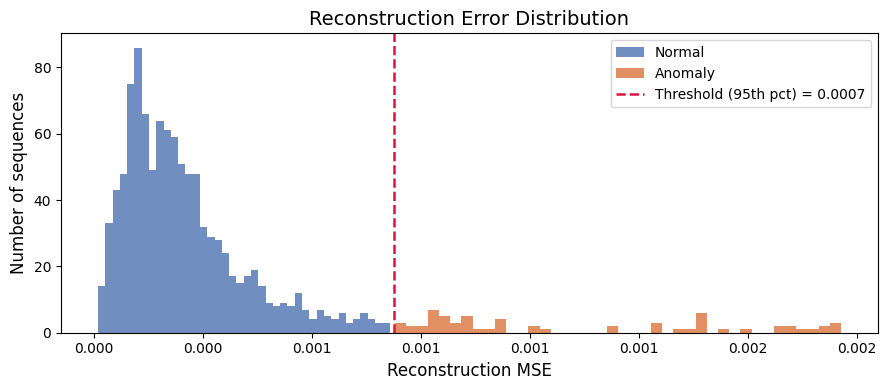

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(all_errors[~is_anomaly], bins=40, color="#4C72B0", alpha=0.8, label="Normal")
ax.hist(all_errors[is_anomaly],  bins=40, color="#DD8452", alpha=0.9, label="Anomaly")
ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.8,
           label=f"Threshold ({THRESHOLD_PERCENTILE}th pct) = {threshold:.4f}")

ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_ylabel("Number of sequences", fontsize=12)
ax.set_title("Reconstruction Error Distribution", fontsize=14)
ax.legend()
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.show()

### Plot 2 — Reconstruction Error by Category

Box plot of reconstruction errors split by spending category. Categories where the model struggles most (high median or wide spread) indicate spending patterns that are harder to learn.

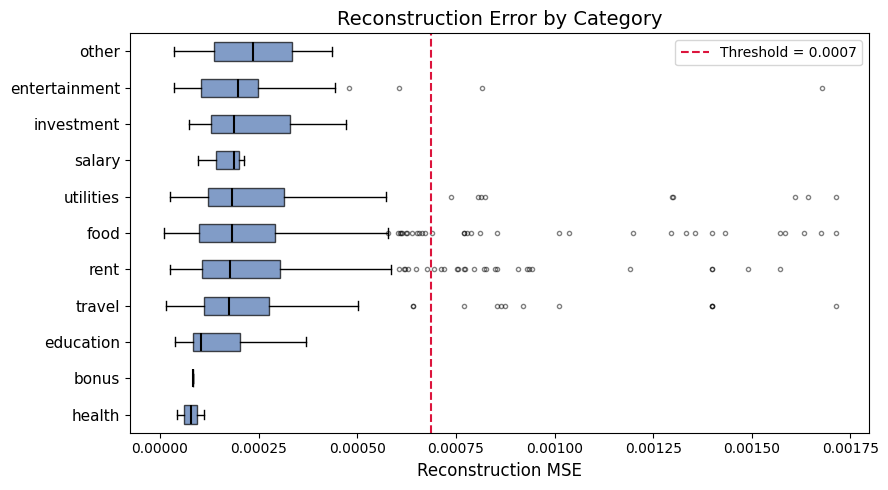

In [13]:
import pandas as pd

results_df = pd.DataFrame({
    "category": categories,
    "mse": all_errors,
    "is_anomaly": is_anomaly,
})

# Order categories by median error (descending) so worst are on top
cat_order = (
    results_df.groupby("category")["mse"]
    .median()
    .sort_values(ascending=True)
    .index.tolist()
)

grouped = [results_df.loc[results_df["category"] == c, "mse"].values for c in cat_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(grouped, vert=False, patch_artist=True,
                medianprops=dict(color="black", linewidth=1.5),
                flierprops=dict(marker="o", markersize=3, alpha=0.5))

for patch in bp["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.7)

ax.axvline(threshold, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Threshold = {threshold:.4f}")
ax.set_yticks(range(1, len(cat_order) + 1))
ax.set_yticklabels(cat_order, fontsize=11)
ax.set_xlabel("Reconstruction MSE", fontsize=12)
ax.set_title("Reconstruction Error by Category", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Plot 3 — Anomaly Count by Category

Bar chart showing how many sequences were flagged per category.

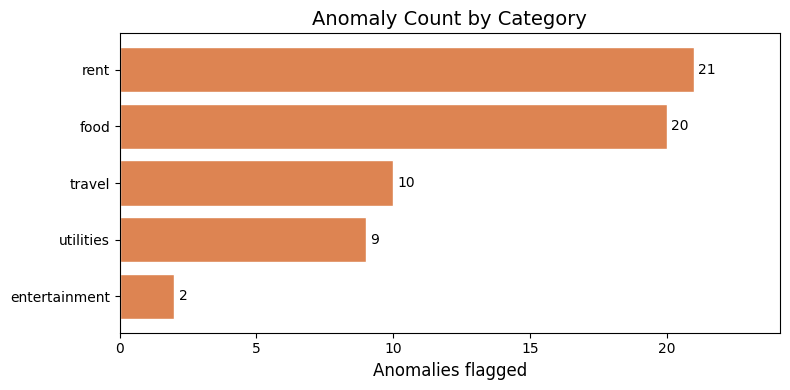

In [14]:
anomaly_counts = (
    results_df[results_df["is_anomaly"]]
    .groupby("category")
    .size()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(anomaly_counts.index, anomaly_counts.values, color="#DD8452", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_xlabel("Anomalies flagged", fontsize=12)
ax.set_title("Anomaly Count by Category", fontsize=14)
ax.set_xlim(0, anomaly_counts.max() * 1.15)
plt.tight_layout()
plt.show()